# Week 2 Task: E-Commerce Sales Database

## Objective

Analyze customer, product, and sales data using SQL queries involving filtering, aggregation, joins, constraints, and business analysis operations.

## Tools Used

- PostgreSQL
- pgAdmin 4
- SQL
- Jupyter Notebook

# Section A — SQL Basics

## Q1. Write a query to display all columns and rows from the customer's table.

In [ ]:
SELECT *
FROM customers;

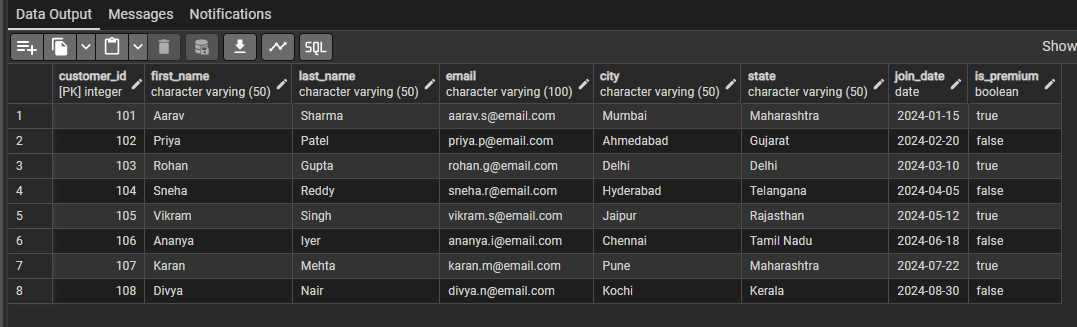

### Observation

The query displays all customer records along with their city, state, join date, and premium membership status.

## Q2. Retrieve only the first_name, last_name, and city of all customers. 

In [ ]:
SELECT
    first_name,
    last_name,
    city
FROM customers;

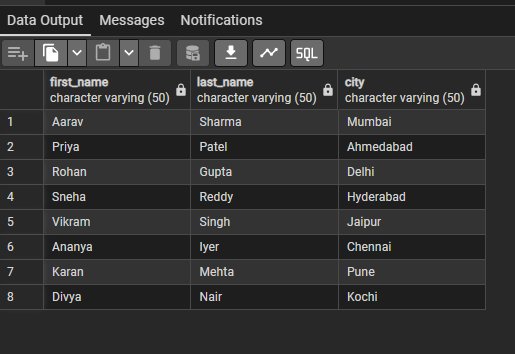

### Observation

The query retrieves selected customer identity and location details from the database.

## Q3. List all unique categories available in the products table

In [ ]:
SELECT DISTINCT category
FROM products;

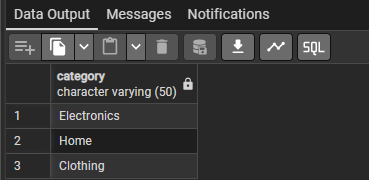

### Observation

The products table contains categories such as Electronics, Clothing, and Home.

## Q4. Identify the Primary Key of each table in the schema. Explain why a Primary Key must be unique and NOT NULL. 

Primary Keys:
- customers table → customer_id
- products table  → product_id
- orders table → order_id
- order_items table → item_id

Since the primary key helps in identifyng the each record in a table uniquely and thus cannot contain the NULL values
Also it helps in maintaining data integrity and supports relationshps between differnet  tables of a database. 

## Q5. What constraints are applied to the email column in the customers table? What would happen if you tried to insert a duplicate email? 

The email column contains:
- UNIQUE constraint
- NOT NULL constraint

The UNIQUE constraints prevent duplicate email entries, i.e. we can not put same email which helps in ensuring Data Intgerity in database,
while the NOT NULL constraint ensures that every customer record contains an email value i.e. we can not leave any cell having NOT NULL constraint defined blank. 

Also On attempting to insert a duplicate/already used email would generate a constraint violation error. As the UNIQUE Constraint got violated. 

## Q6. Try inserting a product with unit_price = -50. What happens and which constraint prevents it? Write both the INSERT statement and explain the error. 

In [ ]:
INSERT INTO products
VALUES (
    999,
    'Test Product',
    'Electronics',
    'TestBrand',
    -50,
    10
);

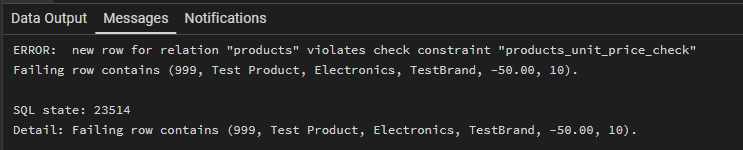

### Observation

The insertion fails because the products table contains a CHECK constraint:

CHECK (unit_price > 0)

This prevents invalid negative product prices from being inserted into the database.

# Section B — Filtering and Optimization

## Q7. Retrieve all orders with status = 'Delivered'. 

In [ ]:
SELECT *
FROM orders
WHERE status = 'Delivered';

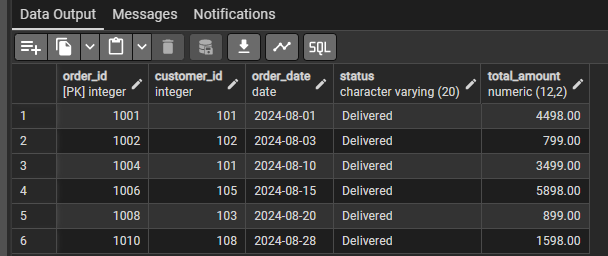

### Observation

The query filters all successfully delivered customer orders from the orders table.

## Q8. Find all Electronics products with unit_price greater than ₹2000

In [ ]:
SELECT *
FROM products
WHERE category = 'Electronics'
AND unit_price > 2000;

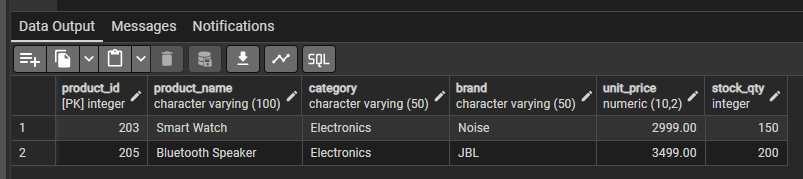

### Observation

The query identifies premium electronic products with higher pricing.

## Q9. List all customers who joined in the year 2024 and belong to the state 'Maharashtra'.

In [ ]:
SELECT *
FROM customers
WHERE state = 'Maharashtra'
AND join_date BETWEEN '2024-01-01' AND '2024-12-31';

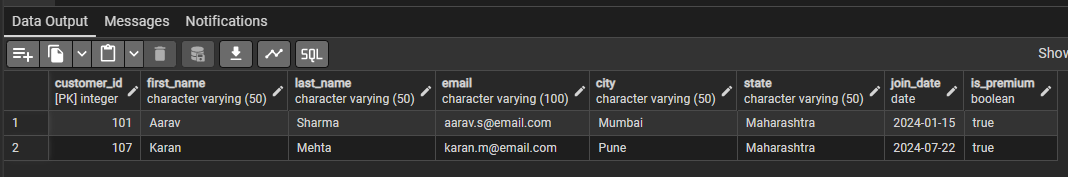

### Observation

The query filters customers based on both geographical location and joining period.

## Q10. Find all orders placed between '2024-08-10' and '2024-08-25' (inclusive) that are NOT cancelled.

In [ ]:
SELECT *
FROM orders
WHERE order_date BETWEEN '2024-08-10' AND '2024-08-25'
AND status != 'Cancelled';

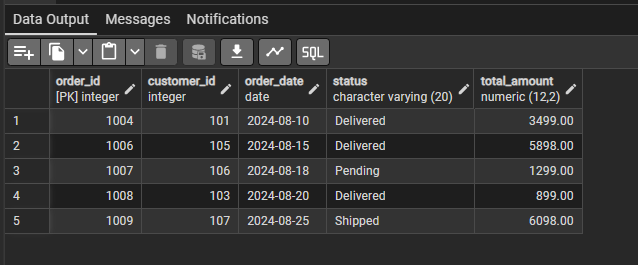

### Observation

The query retrieves valid active orders placed within a specific time period.

## Q11. Explain what the index idx_orders_date does. How would it improve the performance of a query that filters orders by order_date? Write a sample query that would benefit from this index.

Purpose of idx_orders_date Index

The idx_orders_date index improves query performance for operations involving filtering or sorting by order_date.

Indexes reduce the number of rows scanned during query execution and help retrieve results faster.

# Example Query

In [ ]:
SELECT *
FROM orders
WHERE order_date BETWEEN '2024-08-01' AND '2024-08-31';

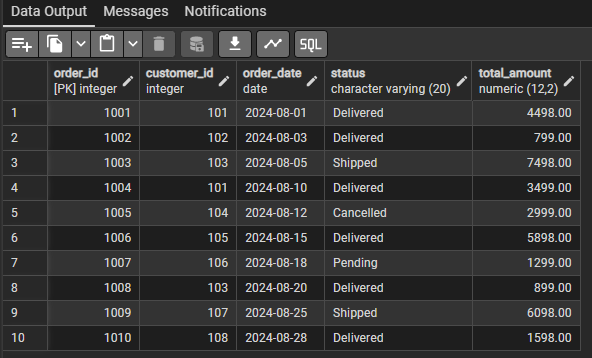

### Observation

Date indexes are useful for reporting, sales analysis, and time-based business queries.

## Q12. If you run: SELECT * FROM customers WHERE YEAR(join_date) = 2024; — would the index on join_date be used? Explain why or why not, and rewrite the query to be index-friendly (SARGable).

## 

The following query is NOT index-friendly:

SELECT * FROM customers
WHERE EXTRACT(YEAR FROM join_date) = 2024;

Using functions on indexed columns can prevent efficient index usage.

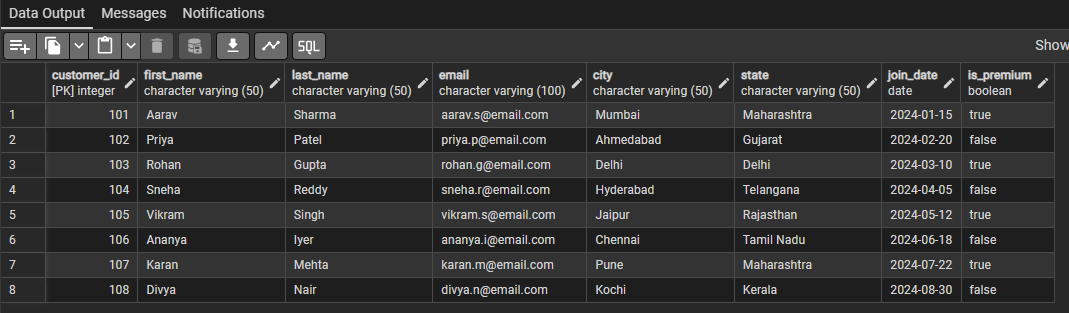

### Observation

Using direct range filtering allows PostgreSQL to use indexes more efficiently and improves query performance.

# Section C — Aggregation (GROUP BY, SUM, COUNT, AVG, MIN, MAX)

# Q13. Count the total number of orders in the orders table. 

In [ ]:
SELECT COUNT(*) AS total_orders
FROM orders;

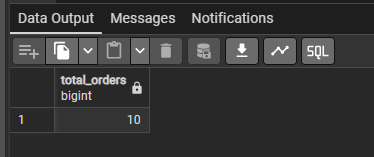

### Observation

The query counts the total number of orders present in the orders table.

## Q14. Find the total revenue (SUM of total_amount) from all 'Delivered' orders.

In [ ]:
SELECT
    SUM(total_amount) AS total_revenue
FROM orders
WHERE status = 'Delivered';

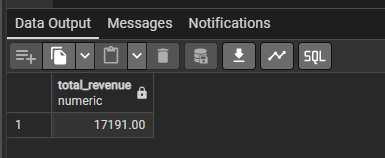

### Observation

The query calculates the total revenue generated from successfully delivered orders.

# Q15. Calculate the average unit_price of products in each category.

In [ ]:
SELECT
    product_id,
    SUM(quantity) AS total_quantity
FROM order_items
GROUP BY product_id;

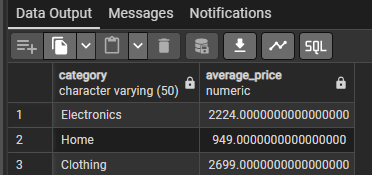

### Observation

The query calculates the average product price for each category.

## Q16. For each order status, find the count of orders and the total revenue. Sort the result by total revenue in descending order.

In [ ]:
SELECT
    status,
    COUNT(*) AS total_orders,
    SUM(total_amount) AS total_revenue
FROM orders
GROUP BY status
ORDER BY total_revenue DESC;

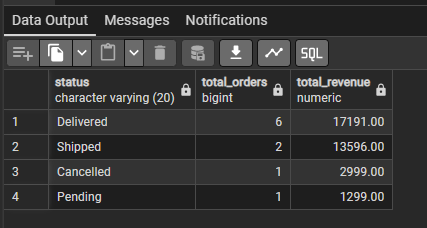

### Observation

The query shows the number of orders and revenue generated for each order status.

# Q17. Find the most expensive (MAX) and cheapest (MIN) product in each category.

In [ ]:
SELECT
    category,
    MAX(unit_price) AS highest_price,
    MIN(unit_price) AS lowest_price
FROM products
GROUP BY category;

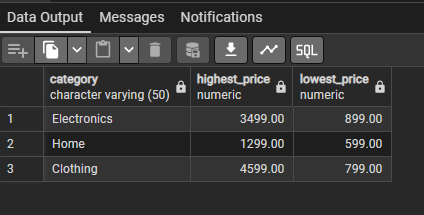

### Observation

The query identifies the highest-priced and lowest-priced products within each category.

## Q18. List all product categories where the average unit_price is greater than ₹2000. (Hint: Use HAVING clause)

In [ ]:
SELECT
    category,
    AVG(unit_price) AS average_price
FROM products
GROUP BY category
HAVING AVG(unit_price) > 2000;

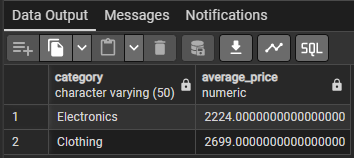

### Observation

The query filters categories where the average product price is greater than ₹2000 using the HAVING clause.

# Section D — Joins & Relationships

## Q19. Write an INNER JOIN query to display each order along with the customer's first_name and last_name. Show: order_id, order_date, first_name, last_name, total_amount.

In [ ]:
SELECT
    orders.order_id,
    orders.order_date,
    customers.first_name,
    customers.last_name,
    orders.total_amount
FROM orders
INNER JOIN customers
ON orders.customer_id = customers.customer_id;

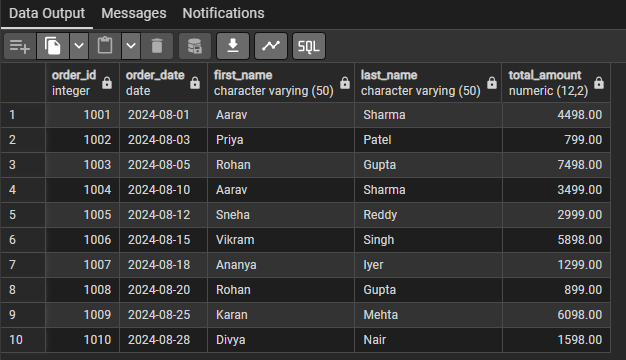

### Observation

The INNER JOIN displays orders along with customer names by matching customer_id from both tables.

## Q20. Using a LEFT JOIN, list ALL customers and their orders (if any). Customers with no orders should still appear with NULL values for order columns. 

In [ ]:
SELECT
    customers.customer_id,
    customers.first_name,
    customers.last_name,
    orders.order_id,
    orders.total_amount
FROM customers
LEFT JOIN orders
ON customers.customer_id = orders.customer_id;

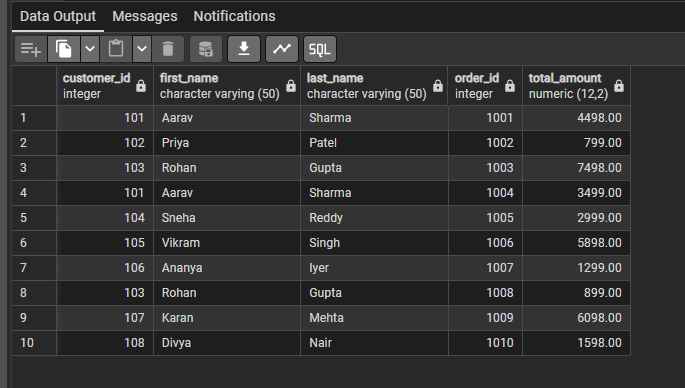

### Observation

The LEFT JOIN displays all customers even if they have not placed any orders.

## Q21. Write a query using JOINs across three tables (orders → order_items → products) to show: order_id, product_name, quantity, unit_price, and discount_pct for each order item. 

In [ ]:
SELECT
    orders.order_id,
    products.product_name,
    order_items.quantity,
    order_items.unit_price,
    order_items.discount_pct
FROM orders
JOIN order_items
ON orders.order_id = order_items.order_id
JOIN products
ON order_items.product_id = products.product_id;

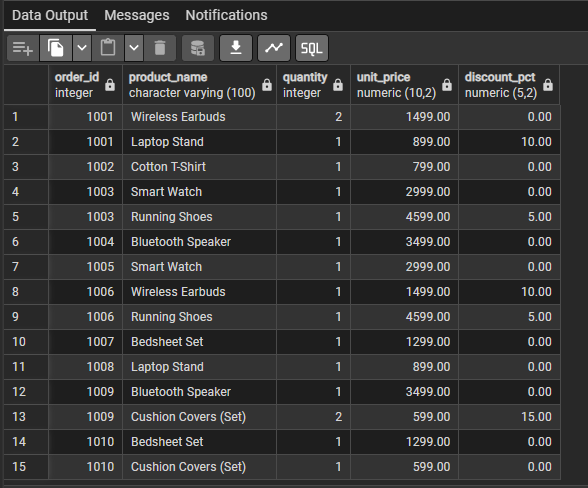

### Observation

The query combines order details, product information, quantity, and pricing using JOIN operations.

## Q22. Explain the difference between LEFT JOIN and RIGHT JOIN with an example from this schema. When would you use a FULL OUTER JOIN?

### Difference Between LEFT JOIN and RIGHT JOIN

- LEFT JOIN returns all records from the left table and matching records from the right table.
- RIGHT JOIN returns all records from the right table and matching records from the left table.

A FULL OUTER JOIN is used when we want all matching and non-matching records from both tables.

## Q23. Identify all Foreign Key relationships in the schema. Explain what would happen if you tried to insert an order with customer_id = 999 (which doesn't exist in customers). 

### Foreign Key Relationships:

- orders.customer_id → customers.customer_id
- order_items.order_id → orders.order_id
- order_items.product_id → products.product_id

Foreign Keys help maintain referential integrity between related tables.

If we try to insert an order with customer_id = 999 (which does not exist in the customers table), PostgreSQL will generate a foreign key constraint violation error.

# Final Conclusion

Through this assignment, I gained practical understanding of SQL concepts such as filtering, aggregation functions, constraints, indexing, and JOIN operations using PostgreSQL.

Working on the e-commerce database helped me understand how relational databases are used to manage customer, product, and order-related information in real-world business scenarios. I also learned how different SQL queries can be used to extract meaningful insights and improve data analysis skills.